# Librerías

In [1]:
import numpy as np #para manejar arreglos
from matplotlib import pyplot as plt #para graficar

from numpy.fft import fft, fftfreq #para Fourier
# https://numpy.org/doc/stable/reference/routines.fft.html
# fft calcula la transformada
# fftfreq calcula las (posibles) frecuencias involucradas

plt.rcParams["figure.figsize"] = (10,5) #tamaño de los gráficos: ancho x alto

---
# Números complejos en Python

In [2]:
a = 4+3j #la j es el i imaginario
print('El número complejo:', a)
print('El valor absoluto del número complejo:', abs(a))

El número complejo: (4+3j)
El valor absoluto del número complejo: 5.0


---
# Calculamos los coeficientes del polinomio trigonométrico que aproxima a $f(t)$:
- ## Caso $f(t)$ periódica **y armónica compleja**.

Text(0, 0.5, 'Función')

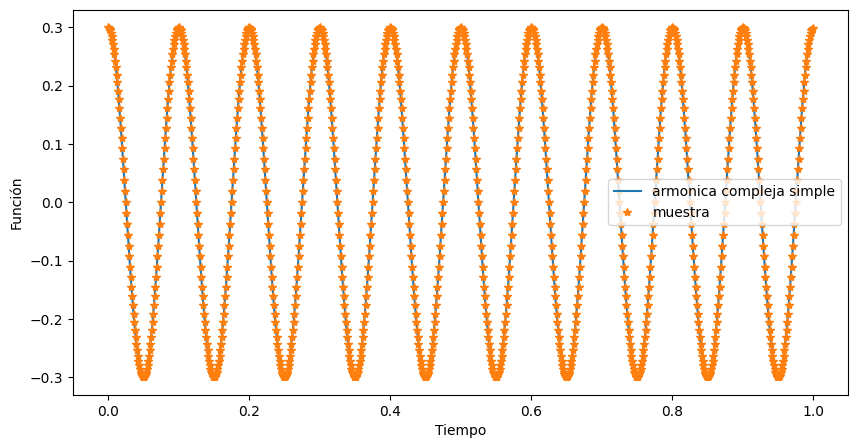

In [10]:
# Esta celda es solamente para entender el papel de la amplitud y la frecuencia.

# CONTAR PORQUÉ el 2*pi: solamente para trabajar en el [0,1) y no en el [0, 2*pi)

def simple_compleja(a,f,t):
  y = a*np.exp(1j*2*np.pi*f*t)
  return y

def f_simple_compleja(t):
  # cambiar a y f e interpretar qué está pasando
  a = 0.3
  f = 10
  y = simple_compleja(a,f,t)
  return y

# muestra de la función teórica
freq_muestreo1 = 1000
paso_temporal1 = 1/freq_muestreo1
vals_t1 = np.arange(0, 1, paso_temporal1) #inicio, fin, paso. No llega hasta el último
vals_f1 = f_simple_compleja(vals_t1)

plt.plot(vals_t1, vals_f1, label="armonica compleja simple")
plt.plot(vals_t1, vals_f1,'*', label="muestra")
plt.legend()
plt.xlabel('Tiempo')
plt.ylabel('Función')

Text(0, 0.5, 'Función')

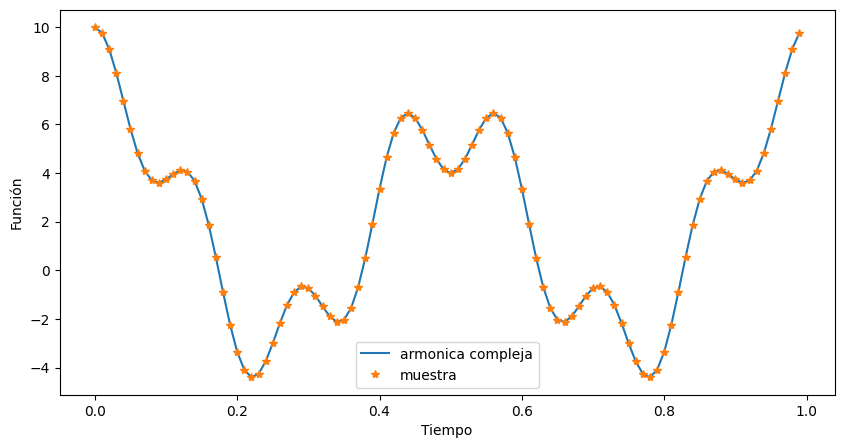

In [9]:
# función teórica a aproximar
def f_armonica_compleja(t):
  a1 = 1
  f1 = 1 # cambiar a 0.5 y mostrar qué pasa: arreglar el intervalo de tiempo

  a2 = 2
  f2 = 7

  a3 = 5
  f3 = 2

  y =  2 + simple_compleja(a1,f1,t) + simple_compleja(a2,f2,t) + simple_compleja(a3,f3,t)
  return y

# muestra de la función teórica
freq_muestreo2 = 100
paso_temporal2 = 1/freq_muestreo2
vals_t2 = np.arange(0, 1, paso_temporal2) #inicio, fin, paso. No llega hasta el último
vals_f2 = f_armonica_compleja(vals_t2)

# Mostrar varios intervalos temporales:
# - Caso chico: longitudes 1, 2, 3, 4, por ejemplo.
# - Caso grande pero no se pega bien con las frecuencias
# - Caso muy grande y no importa lo anterior

plt.plot(vals_t2, vals_f2, label="armonica compleja")
plt.plot(vals_t2, vals_f2,'*', label="muestra")
plt.legend()
plt.xlabel('Tiempo')
plt.ylabel('Función')

## Calculamos los coeficientes del polinomio trigonométrico que aproxima a $f$. Para esto usamos la transformada discreta de Fourier.

### Mostrar: https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/chapter24.02-Discrete-Fourier-Transform.html

(-2.0, 10.0)

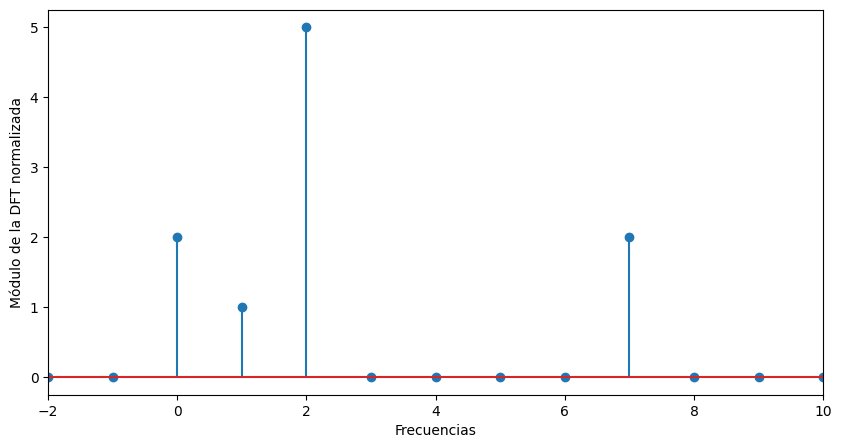

In [13]:
# transformada de Fourier de la muestra de f
vals_f_fourier2 = fft(vals_f2)

# Calculo las posibles frecuencias involucradas en la aproximación
cantidad_muestras2 = len(vals_t2)
frecuencias2 = fftfreq(cantidad_muestras2, d=paso_temporal2)

# grafico frecuencias vs. amplitudes
# plt.stem(frecuencias2, abs(vals_f_fourier2) )
plt.stem(frecuencias2, abs(vals_f_fourier2)/cantidad_muestras2 )
plt.xlabel('Frecuencias')
plt.ylabel('Módulo de la DFT normalizada')
plt.xlim(-2,10)


# imprimir la transformada y reconstruir el polinomio (es decir la función).

# VARIAR LA CANTIDAD DE MUESTRAS (i.e. la freq de muestreo) y discutir qué pasa.

---
---
# Calculamos los coeficientes del polinomio trigonométrico que aproxima a $f(t)$:
- ## Caso $f(t)$ periódica **y armónica real**.

Text(0, 0.5, 'Función')

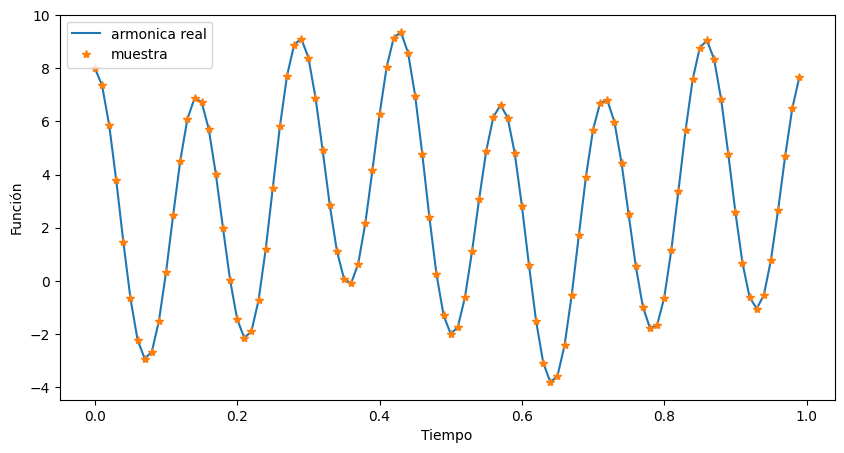

In [15]:
def simple_seno(a,f,t):
  y = a*np.sin(2*np.pi*f*t)
  return y

def simple_coseno(a,f,t):
  y = a*np.cos(2*np.pi*f*t)
  return y


def f_armonica_real(t):
  a1 = 0.5
  f1 = 1

  a2 = -1.5
  f2 = 2

  a3 = 5
  f3 = 7

  y =  3 + simple_seno(a1,f1,t) + simple_seno(a2,f2,t) + simple_coseno(a3,f3,t)
  return y

freq_muestreo3 = 100
paso_temporal3 = 1/freq_muestreo3
vals_t3 = np.arange(0,1,paso_temporal3)
vals_f3 = f_armonica_real(vals_t3)

plt.plot(vals_t3, vals_f3, label="armonica real")
plt.plot(vals_t3,vals_f3,'*', label="muestra")
plt.legend()
plt.xlabel('Tiempo')
plt.ylabel('Función')

## Calculamos los coeficientes del polinomio trigonométrico que aproxima a $f$. Para esto usamos la transformada discreta de Fourier.

(-9.0, 9.0)

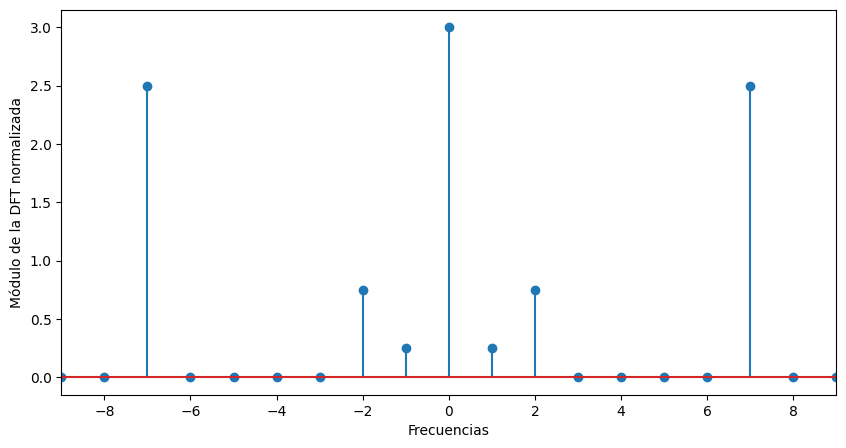

In [17]:
vals_f_fourier3 = fft(vals_f3)

cantidad_muestras3 = len(vals_t3)
frecuencias3 = fftfreq(cantidad_muestras3, d=paso_temporal3)

# plt.stem(frecuencias3, abs(vals_f_fourier3) )
plt.stem(frecuencias3, abs(vals_f_fourier3)/cantidad_muestras3 )
plt.xlabel('Frecuencias')
plt.ylabel('Módulo de la DFT normalizada')
plt.xlim(-9,9)

---
---
# Calculamos los coeficientes del polinomio trigonométrico que aproxima a $f(t)$:
- ## Caso $f(t)$ periódica **cualquiera**.

Text(0, 0.5, 'Función')

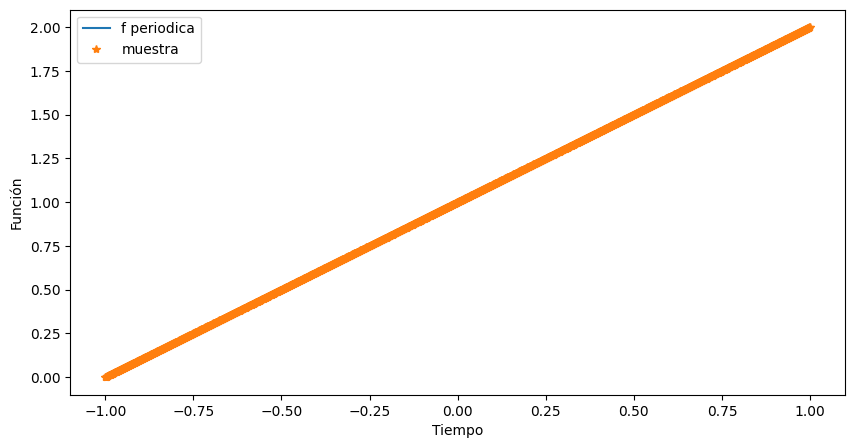

In [25]:
def f_periodica(t):
  # y = t
  y = t + 1 #cambiar y ver que el +1 es el coef 0 (que en el gráfico es por 2)
  return y

freq_muestreo4 = 1000
paso_temporal4 = 1/freq_muestreo4
vals_t4 = np.arange(-1,1,paso_temporal4) #no llega hasta el 1
vals_f4 = f_periodica(vals_t4)

plt.plot(vals_t4, vals_f4, label="f periodica")
plt.plot(vals_t4,vals_f4,'*', label="muestra")
plt.legend()
plt.xlabel('Tiempo')
plt.ylabel('Función')

(-5.0, 5.0)

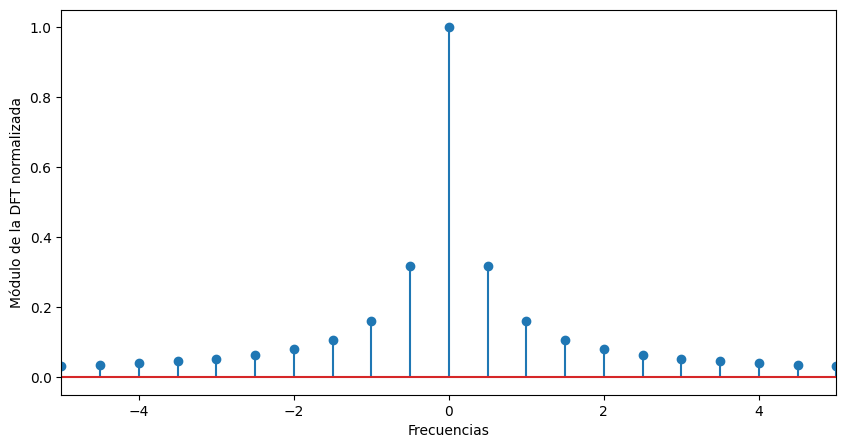

In [27]:
vals_f_fourier4 = fft(vals_f4)

cantidad_muestras4 = len(vals_t4)
frecuencias4 = fftfreq(cantidad_muestras4, d=paso_temporal4)

plt.stem(frecuencias4, abs(vals_f_fourier4)/cantidad_muestras4 )
plt.xlabel('Frecuencias')
plt.ylabel('Módulo de la DFT normalizada')
plt.xlim(-5,5)

---
## Mostrar la NB con la aproximación por series de Fourier de una $f$ periódica cualquiera.

---
# **Ejercicio:** el 6 de la guía.
## Charlar frecuencias que aparecen.

